# Hello world

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Train/val split

In [3]:
Data_DIR = "../data/images/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 1337

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    Data_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",

)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    Data_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",

)

class_names = train_ds_raw.class_names
num_classes = len(class_names)


train_ds = train_ds_raw
val_ds = val_ds_raw


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [4]:
print(IMG_SIZE + (3,), BATCH_SIZE, SEED)

(224, 224, 3) 32 1337


## Baseline and compile

In [4]:
base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
    ],
)

## Fit the base-model

In [ ]:
history_clean = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 129s 232ms/step - loss: 1.3007 - top1: 0.7246 - top5: 0.9261 - val_loss: 0.5679 - val_top1: 0.8421 - val_top5: 0.9876
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 117s 228ms/step - loss: 0.4922 - top1: 0.8625 - top5: 0.9880 - val_loss: 0.4734 - val_top1: 0.8591 - val_top5: 0.9886
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 117s 227ms/step - loss: 0.3802 - top1: 0.8941 - top5: 0.9930 - val_loss: 0.4561 - val_top1: 0.8530 - val_top5: 0.9881
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 115s 223ms/step - loss: 0.3105 - top1: 0.9114 - top5: 0.9956 - val_loss: 0.4442 - val_top1: 0.8630 - val_top5: 0.9871
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 114s 221ms/step - loss: 0.2632 - top1: 0.9255 - top5: 0.9976 - val_loss: 0.4325 - val_top1: 0.8601 - val_top5: 0.9869


## Corrupt

### Random noice

In [5]:
def add_noise(img, label, std=255.0,mean=-50.0):
    noise = tf.random.normal(tf.shape(img), mean=mean, stddev=std)
    img = tf.clip_by_value(img + noise, 0.0, 255.0)
    return img, label

val_ds_noise = (val_ds_raw
                .map(lambda img, label: add_noise(img, label, std=40.0)))

### Jpeg compression

In [6]:
def jpeg_compression(img, label, quality=1):
    img = tf.cast(img, tf.uint8)                 
    x = tf.io.encode_jpeg(img, quality=quality)
    img = tf.io.decode_jpeg(x, channels=3)
    img = tf.cast(img, tf.float32)
    return img, label


val_ds_jpeg = (val_ds_raw
               .unbatch()
               .map(lambda x, y: jpeg_compression(x, y),)
               .batch(BATCH_SIZE))

### Blur

In [7]:
def blur(img, label, k=5):
    img4 = tf.expand_dims(img, 0) 
    img4 = tf.nn.avg_pool2d(img4, ksize=k, strides=1, padding="SAME")
    img = tf.squeeze(img4, 0)      
    return img, label

val_ds_blur = (val_ds_raw
               .unbatch()
               .map(lambda x, y: blur(x, y),)
               .batch(BATCH_SIZE))


In [16]:
print("CLEAN:")
model2.evaluate(val_ds)

print("NOISY:")
model2.evaluate(val_ds_noise)

print("JPEG:")
model2.evaluate(val_ds_jpeg)

print("BLURRED:")
model2.evaluate(val_ds_blur)

CLEAN:
129/129 ━━━━━━━━━━━━━━━━━━━━ 26s 200ms/step - loss: 0.4449 - top1: 0.8569 - top5: 0.9862
NOISY:
129/129 ━━━━━━━━━━━━━━━━━━━━ 27s 207ms/step - loss: 1.8948 - top1: 0.4998 - top5: 0.8069
JPEG:
129/129 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - loss: 3.7695 - top1: 0.1871 - top5: 0.4121
BLURRED:


c:\Users\Emil\Desktop\skola\BDP\BDP\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


129/129 ━━━━━━━━━━━━━━━━━━━━ 26s 204ms/step - loss: 0.8534 - top1: 0.7434 - top5: 0.9448


[0.8534146547317505, 0.7434402108192444, 0.9448493719100952]

## Print

In [14]:
for images, labels in val_ds_raw.take(1):
    original = images[0]
    break

In [15]:
noisy, _ = add_noise(original, None, std=40.0)
jpeg, _ = jpeg_compression(original, None)
blurred, _ = blur(original, None)

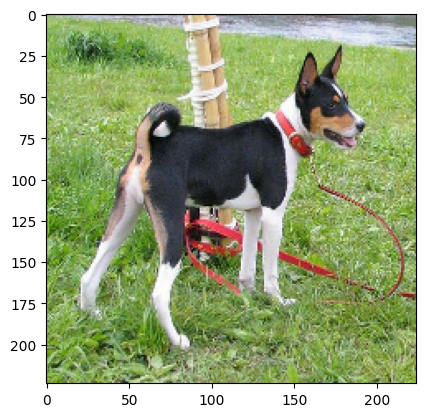

In [11]:
plt.imshow(original.numpy().astype("uint8"))

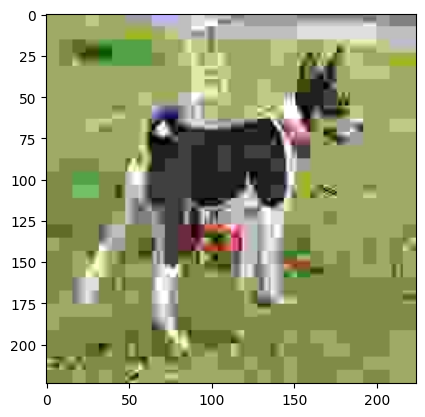

In [12]:
plt.imshow(jpeg.numpy().astype("uint8"))

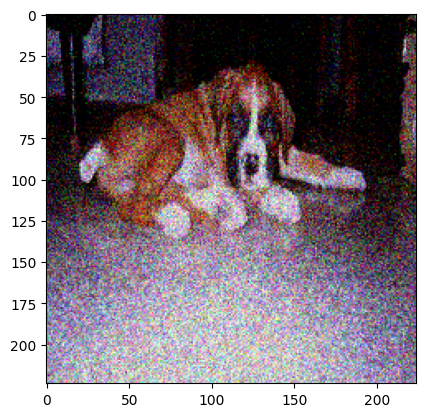

In [96]:
plt.imshow(noisy.numpy().astype("uint8"))

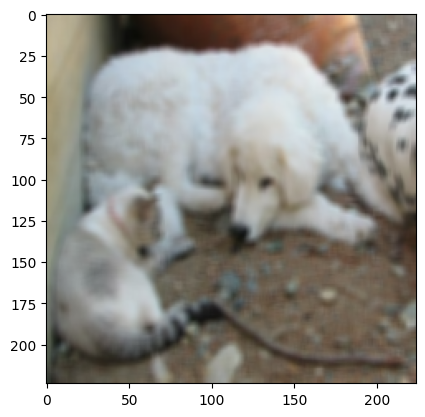

In [16]:
plt.imshow(blurred.numpy().astype("uint8"))

## Corrupt some input data

In [8]:
def corrupt_fraction(train_ds_raw, corrupt_fn, p=0.5, seed=1337, batch_size=32, shuffle=True):

    ds = train_ds_raw.unbatch().enumerate() # Add an index to each element

    def maybe_corrupt(i, data): 
        img, label = data 

        # Create a random number in [0, 1) using a stateless random generator
        r = tf.random.stateless_uniform(
            shape=[], 
            seed=tf.stack([tf.cast(seed, tf.int32), tf.cast(i, tf.int32)]), # Use the index as part of the seed to ensure different random numbers for each element
            
        )
    
        return tf.cond(
            r < p,
            lambda: corrupt_fn(img, label), # true case: apply corruption
            lambda: (img, label) # false case: return original
        )

    ds = ds.map(maybe_corrupt)
    if shuffle:
        ds = ds.shuffle(2000, seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)
    return ds

## Blur

In [11]:
base2 = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base2.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base2(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model2 = tf.keras.Model(inputs, outputs)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
    ],
)

In [10]:
train_blur5 = corrupt_fraction(
    train_ds_raw,
    corrupt_fn=lambda img, lab: blur(img, lab, k=5),
    seed=SEED,
    batch_size=BATCH_SIZE,
)

In [12]:
history_blur = model2.fit(train_blur5, validation_data=val_ds, epochs=5)

Epoch 1/5
    515/Unknown 113s 210ms/step - loss: 2.4962 - top1: 0.4899 - top5: 0.7374

c:\Users\Emil\Desktop\skola\BDP\BDP\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 142s 267ms/step - loss: 1.5909 - top1: 0.6463 - top5: 0.8830 - val_loss: 0.6089 - val_top1: 0.8377 - val_top5: 0.9849
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 139s 269ms/step - loss: 0.7364 - top1: 0.7956 - top5: 0.9680 - val_loss: 0.5032 - val_top1: 0.8472 - val_top5: 0.9871
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 136s 264ms/step - loss: 0.6010 - top1: 0.8264 - top5: 0.9779 - val_loss: 0.4702 - val_top1: 0.8513 - val_top5: 0.9859
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 134s 260ms/step - loss: 0.5288 - top1: 0.8428 - top5: 0.9823 - val_loss: 0.4608 - val_top1: 0.8545 - val_top5: 0.9881
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 134s 260ms/step - loss: 0.4660 - top1: 0.8591 - top5: 0.9862 - val_loss: 0.4449 - val_top1: 0.8569 - val_top5: 0.9862


## Jpeg

In [17]:
base3 = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base3.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base3(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model3 = tf.keras.Model(inputs, outputs)

model3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
    ],
)

In [20]:
train_jpeg = corrupt_fraction(
    train_ds_raw,
    corrupt_fn=lambda img, label: jpeg_compression(img, label, quality=1),
    seed=SEED,
    batch_size=BATCH_SIZE,
)

In [21]:
history_jpeg = model3.fit(train_jpeg, validation_data=val_ds, epochs=5)

Epoch 1/5
    515/Unknown 116s 217ms/step - loss: 3.4602 - top1: 0.2842 - top5: 0.4848

c:\Users\Emil\Desktop\skola\BDP\BDP\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 144s 270ms/step - loss: 2.7606 - top1: 0.4020 - top5: 0.6231 - val_loss: 0.7461 - val_top1: 0.8192 - val_top5: 0.9815
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 136s 263ms/step - loss: 1.9474 - top1: 0.5333 - top5: 0.7422 - val_loss: 0.5693 - val_top1: 0.8348 - val_top5: 0.9835
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 137s 265ms/step - loss: 1.7916 - top1: 0.5596 - top5: 0.7643 - val_loss: 0.5221 - val_top1: 0.8394 - val_top5: 0.9854
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 133s 258ms/step - loss: 1.6916 - top1: 0.5791 - top5: 0.7826 - val_loss: 0.4971 - val_top1: 0.8474 - val_top5: 0.9862
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 134s 260ms/step - loss: 1.6223 - top1: 0.5980 - top5: 0.7956 - val_loss: 0.4810 - val_top1: 0.8460 - val_top5: 0.9864


## Random Noice

In [9]:
base4 = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base4.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base4(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model4 = tf.keras.Model(inputs, outputs)

model4.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
    ],
)

In [11]:
train_noice = corrupt_fraction(
    train_ds_raw,
    corrupt_fn=lambda img, label: add_noise(img, label, std=255.0,mean=-50.0),
    seed=SEED,
    batch_size=BATCH_SIZE,
)

In [12]:
history_jpeg = model4.fit(train_noice, validation_data=val_ds, epochs=5)

Epoch 1/5
    515/Unknown 107s 196ms/step - loss: 3.8863 - top1: 0.2275 - top5: 0.3626

c:\Users\Emil\Desktop\skola\BDP\BDP\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 133s 246ms/step - loss: 3.3309 - top1: 0.3271 - top5: 0.4632 - val_loss: 0.7652 - val_top1: 0.8132 - val_top5: 0.9825
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 122s 232ms/step - loss: 2.7387 - top1: 0.4216 - top5: 0.5274 - val_loss: 0.5687 - val_top1: 0.8404 - val_top5: 0.9866
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 122s 233ms/step - loss: 2.6559 - top1: 0.4375 - top5: 0.5326 - val_loss: 0.5156 - val_top1: 0.8482 - val_top5: 0.9862
Epoch 4/5


KeyboardInterrupt: 

# f

In [353]:
for images, labels in train_blur5.take(1):
    original = images[0]
    break

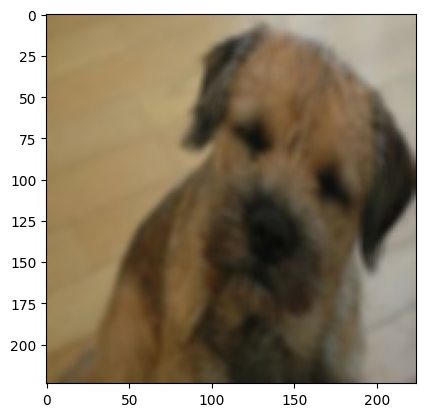

In [354]:
plt.imshow(original.numpy().astype("uint8"))